In [1]:
import numpy as np
import pandas as pd
np.random.seed(42)
num_rows = 5000
url_length = np.random.randint(12, 160, num_rows)       
qty_dots = np.random.randint(1, 6, num_rows)               
qty_hyphens = np.random.randint(0, 5, num_rows)            
subdomain_count = np.random.randint(1, 5, num_rows)        
has_at_symbol = np.random.choice([0, 1], num_rows, p=[0.94, 0.06])  
is_ip_in_url = np.random.choice([0, 1], num_rows, p=[0.96, 0.04])   
is_shortened = np.random.choice([0, 1], num_rows, p=[0.88, 0.12])   
domain_age_months = np.random.randint(1, 240, num_rows)    
has_valid_ssl = np.random.choice([0, 1], num_rows, p=[0.35, 0.65])   
google_trust_score = np.random.uniform(0, 100, num_rows)   
external_redirects = np.random.randint(0, 5, num_rows)     
is_free_hosting = np.random.choice([0, 1], num_rows, p=[0.90, 0.10])
has_scam_keywords = np.random.choice([0, 1], num_rows, p=[0.75, 0.25])
fraud_score = (url_length * 0.02) + (qty_hyphens * 0.4) + (is_shortened * 1.5) + (is_ip_in_url * 2.5) + \
              (external_redirects * 0.5) + (is_free_hosting * 1.2) + (has_scam_keywords * 1.0) - \
              (domain_age_months * 0.03) - (has_valid_ssl * 1.8) - (google_trust_score * 0.015)
is_fake_website = np.where(fraud_score > np.median(fraud_score), 1, 0)
df = pd.DataFrame({
    'URL_Length': url_length,
    'Qty_Dots': qty_dots,
    'Qty_Hyphens': qty_hyphens,
    'Subdomain_Count': subdomain_count,
    'Has_At_Symbol': has_at_symbol,
    'Is_IP_In_URL': is_ip_in_url,
    'Is_Shortened_URL': is_shortened,
    'Domain_Age_Months': domain_age_months,
    'Has_Valid_SSL': has_valid_ssl,
    'Google_Trust_Score': np.round(google_trust_score, 1),
    'External_Redirect_Count': external_redirects,
    'Is_Free_Hosting_Domain': is_free_hosting,
    'Has_Scam_Keywords': has_scam_keywords,
    'Is_Fake_Website': is_fake_website
})
df.head()


,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,114,3,1,3,0,0,0,134,0,96.6,3,0,0,1
1,104,4,2,1,0,0,0,167,0,59.7,0,0,0,0
2,26,4,1,4,0,0,0,157,0,69.8,0,0,0,0
3,118,3,1,1,0,0,0,155,1,86.1,2,0,0,0
4,83,1,4,4,0,0,0,69,0,84.0,1,1,0,1


In [2]:
df.shape

(5000, 14)

In [3]:
df['URL_Length'].unique()

array([114, 104,  26, 118,  83,  32, 133,  86,  99, 128, 111, 115, 142,
        64,  13,  49, 141,  69,  33, 100,  60,  70,  62, 119,  66,  75,
       146,  84,  29, 143,  71,  25,  20, 101,  95, 103, 122,  19,  46,
        92,  61, 145,  65, 117,  15, 157,  55, 106,  59,  51,  93,  35,
       135,  52,  56,  76,  82, 140, 147,  74, 150,  44, 134,  16,  39,
        23,  73,  48, 110, 112,  12, 153,  38, 148,  53, 107,  63, 154,
        40,  47,  24,  97,  77,  41, 139, 132, 127,  14, 129, 124,  50,
        98, 158, 137,  79, 156,  80, 109, 155, 108,  81, 159,  22,  18,
       123, 151, 131, 121, 126, 130, 120,  72,  28,  57,  17,  78,  36,
       125,  43, 138,  54,  37,  68,  31, 136, 105,  58,  30,  34,  45,
        27,  87,  96,  21, 149,  91,  85, 152, 116,  94, 144, 102,  67,
       113,  89,  90,  42,  88], dtype=int32)

In [4]:
df.tail()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
4995,138,4,4,4,0,0,0,51,0,4.7,3,0,0,1
4996,145,3,2,3,0,0,0,149,1,12.2,1,0,0,0
4997,36,3,4,4,0,0,0,199,1,29.6,3,0,0,0
4998,96,3,4,1,0,0,0,58,1,25.9,1,0,1,1
4999,66,3,4,1,0,0,0,98,1,72.8,3,0,0,0


In [5]:
df.describe

<bound method NDFrame.describe of       URL_Length  Qty_Dots  Qty_Hyphens  Subdomain_Count  Has_At_Symbol  \
0            114         3            1                3              0   
1            104         4            2                1              0   
2             26         4            1                4              0   
3            118         3            1                1              0   
4             83         1            4                4              0   
...          ...       ...          ...              ...            ...   
4995         138         4            4                4              0   
4996         145         3            2                3              0   
4997          36         3            4                4              0   
4998          96         3            4                1              0   
4999          66         3            4                1              0   

      Is_IP_In_URL  Is_Shortened_URL  Domain_Age_Months  Has_Vali

In [6]:
df.isnull().sum()

URL_Length                 0
Qty_Dots                   0
Qty_Hyphens                0
Subdomain_Count            0
Has_At_Symbol              0
Is_IP_In_URL               0
Is_Shortened_URL           0
Domain_Age_Months          0
Has_Valid_SSL              0
Google_Trust_Score         0
External_Redirect_Count    0
Is_Free_Hosting_Domain     0
Has_Scam_Keywords          0
Is_Fake_Website            0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   URL_Length               5000 non-null   int32  
 1   Qty_Dots                 5000 non-null   int32  
 2   Qty_Hyphens              5000 non-null   int32  
 3   Subdomain_Count          5000 non-null   int32  
 4   Has_At_Symbol            5000 non-null   int64  
 5   Is_IP_In_URL             5000 non-null   int64  
 6   Is_Shortened_URL         5000 non-null   int64  
 7   Domain_Age_Months        5000 non-null   int32  
 8   Has_Valid_SSL            5000 non-null   int64  
 9   Google_Trust_Score       5000 non-null   float64
 10  External_Redirect_Count  5000 non-null   int32  
 11  Is_Free_Hosting_Domain   5000 non-null   int64  
 12  Has_Scam_Keywords        5000 non-null   int64  
 13  Is_Fake_Website          5000 non-null   int64  
dtypes: float64(1), int32(6),

In [8]:
df.describe

<bound method NDFrame.describe of       URL_Length  Qty_Dots  Qty_Hyphens  Subdomain_Count  Has_At_Symbol  \
0            114         3            1                3              0   
1            104         4            2                1              0   
2             26         4            1                4              0   
3            118         3            1                1              0   
4             83         1            4                4              0   
...          ...       ...          ...              ...            ...   
4995         138         4            4                4              0   
4996         145         3            2                3              0   
4997          36         3            4                4              0   
4998          96         3            4                1              0   
4999          66         3            4                1              0   

      Is_IP_In_URL  Is_Shortened_URL  Domain_Age_Months  Has_Vali

In [9]:
df.dropna()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,114,3,1,3,0,0,0,134,0,96.6,3,0,0,1
1,104,4,2,1,0,0,0,167,0,59.7,0,0,0,0
2,26,4,1,4,0,0,0,157,0,69.8,0,0,0,0
3,118,3,1,1,0,0,0,155,1,86.1,2,0,0,0
4,83,1,4,4,0,0,0,69,0,84.0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,138,4,4,4,0,0,0,51,0,4.7,3,0,0,1
4996,145,3,2,3,0,0,0,149,1,12.2,1,0,0,0
4997,36,3,4,4,0,0,0,199,1,29.6,3,0,0,0
4998,96,3,4,1,0,0,0,58,1,25.9,1,0,1,1


In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,114,3,1,3,0,0,0,134,0,96.6,3,0,0,1
1,104,4,2,1,0,0,0,167,0,59.7,0,0,0,0
2,26,4,1,4,0,0,0,157,0,69.8,0,0,0,0
3,118,3,1,1,0,0,0,155,1,86.1,2,0,0,0
4,83,1,4,4,0,0,0,69,0,84.0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,138,4,4,4,0,0,0,51,0,4.7,3,0,0,1
4996,145,3,2,3,0,0,0,149,1,12.2,1,0,0,0
4997,36,3,4,4,0,0,0,199,1,29.6,3,0,0,0
4998,96,3,4,1,0,0,0,58,1,25.9,1,0,1,1


In [13]:
df.head()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,114,3,1,3,0,0,0,134,0,96.6,3,0,0,1
1,104,4,2,1,0,0,0,167,0,59.7,0,0,0,0
2,26,4,1,4,0,0,0,157,0,69.8,0,0,0,0
3,118,3,1,1,0,0,0,155,1,86.1,2,0,0,0
4,83,1,4,4,0,0,0,69,0,84.0,1,1,0,1


In [14]:
df.isnull()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isnull().sum()

URL_Length                 0
Qty_Dots                   0
Qty_Hyphens                0
Subdomain_Count            0
Has_At_Symbol              0
Is_IP_In_URL               0
Is_Shortened_URL           0
Domain_Age_Months          0
Has_Valid_SSL              0
Google_Trust_Score         0
External_Redirect_Count    0
Is_Free_Hosting_Domain     0
Has_Scam_Keywords          0
Is_Fake_Website            0
dtype: int64

In [16]:
df['Domain_Age_Months'].unique()

array([134, 167, 157, 155,  69, 137, 152, 191, 147,  97, 123, 158, 186,
       168, 119, 196,  32, 113,  65, 162,  85, 159,  59, 206,  26, 150,
       225, 121,  13, 224,  55, 136, 190, 233,  56,  84, 149,  98, 177,
        94,  35, 212, 126, 230,  14,  74,  52, 106, 207,  40,  43, 112,
         3, 143, 173,  95, 139, 238,  19, 148, 214, 199,  78, 118, 132,
         9, 231, 153, 175, 227, 229,  49,  28, 216,  16,  87, 174, 203,
        83,  34, 215, 138, 239,   1,  66, 115, 145,  47,  24, 178, 213,
       104,  29,  72, 222,  86, 141, 192, 156, 133, 142, 102, 161,  75,
        17, 164,  70,  61, 111, 202, 234, 197,  51, 170,  62,  67,  30,
       107, 166,  11,  91,   8, 221,  80, 163, 200,  33,   5, 165,  22,
       160, 236, 182,  18,  63, 135,  57, 187, 105,  71, 171,   6, 110,
        53,  64, 232, 219,   4,  31, 117, 188,  79, 205, 204, 127, 211,
        77,  20, 100,  45, 201,  81, 146,  25, 129,  41,  73,  89,  27,
       169,   7, 209,  99, 144, 130,  54, 179, 180,  82, 208, 18

In [17]:
df['Google_Trust_Score'].unique()

array([ 96.6,  59.7,  69.8,  86.1,  84. ,  71.9,  50. ,  27.3,  87.7,
        77.7,  83.8,  14.1,  31.5,  42.5,  89.3,  28.5,  68.6,   7.8,
        41. ,  48.7,  76.6,  89.2,  33.7,  52.8,  64.7,  32.9,  98.6,
        87.6,  29.6,  50.8,  23.1,  51.5,  68.3,   8.6,  87. ,  59.4,
        99. ,   2.6,  83.1,  79.2,  13.3,  33.5,  88.5,  51.8,  40.1,
        90.5,   9.3,  47.3,  65.2,  60.9,  26.4,  56.3,  70.9,  58.5,
        68.4,  25.6,  83.3,  45. ,  98.7,   2.3,  38. ,  18. ,  55.6,
        24.3,  73.7,  88.2,  21.1,  16.1,  87.5,  36.1,  43.5,  22.1,
        66.6,  49.9,  78.8,  31.3,  50.6,  26. ,  93.4,  52.2,  17.3,
         8.3,   2.8,  52.6,  96.4,  17.1,  79.4,  31.6,  22.4,  97. ,
        80.3,  63.1,  69.7,  99.1,  59.3,  10.2,   6.5,  66.7,  65.8,
        74.8,  10.9,  94.5,  55.1,  65. ,   3.5,  96.1,  94.4,  92.9,
        22. ,  93.1,   1.9,  24. ,  41.3,  58.3,  70.1,  21. ,  83.7,
        84.6,  63.5,  92.1,  81.3,  22.2,  79.9,  95.3,  13.8,  97.9,
         2.5,  77.4,

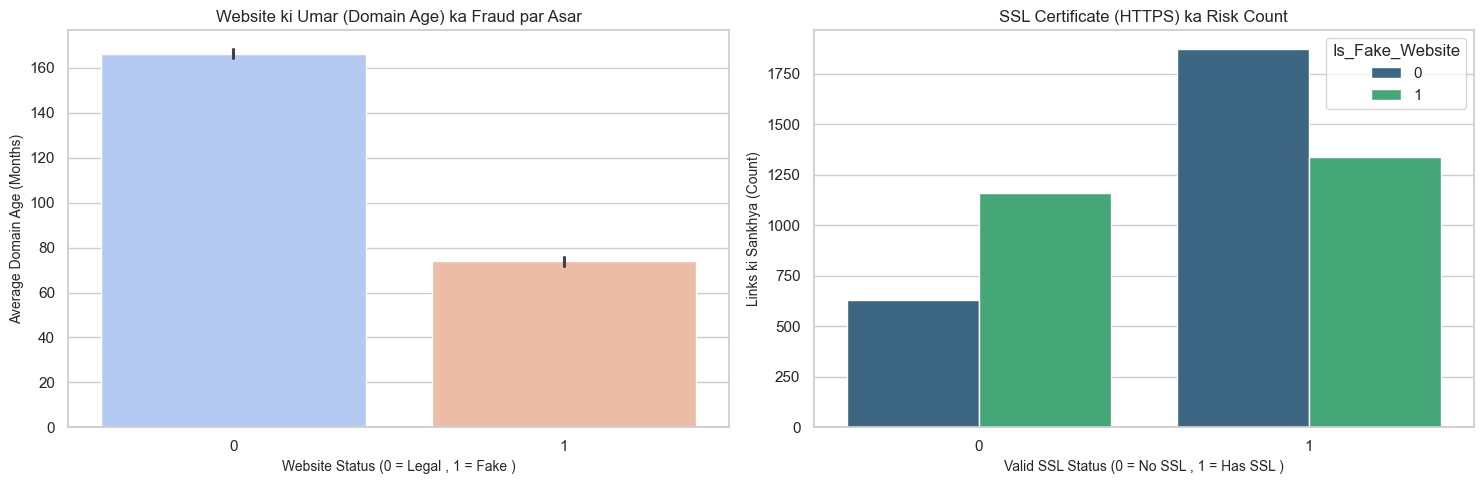

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Is_Fake_Website', y='Domain_Age_Months', hue='Is_Fake_Website', data=df, palette='coolwarm', legend=False)
plt.title('Website ki Umar (Domain Age) ka Fraud par Asar', fontsize=12)
plt.xlabel('Website Status (0 = Legal , 1 = Fake )', fontsize=10)
plt.ylabel('Average Domain Age (Months)', fontsize=10)
plt.subplot(1, 2, 2)
sns.countplot(x='Has_Valid_SSL', hue='Is_Fake_Website', data=df, palette='viridis')
plt.title('SSL Certificate (HTTPS) ka Risk Count', fontsize=12)
plt.xlabel('Valid SSL Status (0 = No SSL , 1 = Has SSL )', fontsize=10)
plt.ylabel('Links ki Sankhya (Count)', fontsize=10)
plt.tight_layout()
plt.show()


In [20]:
df.head()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,114,3,1,3,0,0,0,134,0,96.6,3,0,0,1
1,104,4,2,1,0,0,0,167,0,59.7,0,0,0,0
2,26,4,1,4,0,0,0,157,0,69.8,0,0,0,0
3,118,3,1,1,0,0,0,155,1,86.1,2,0,0,0
4,83,1,4,4,0,0,0,69,0,84.0,1,1,0,1


In [21]:
df.shape

(5000, 14)

In [22]:
df.isnull().sum()

URL_Length                 0
Qty_Dots                   0
Qty_Hyphens                0
Subdomain_Count            0
Has_At_Symbol              0
Is_IP_In_URL               0
Is_Shortened_URL           0
Domain_Age_Months          0
Has_Valid_SSL              0
Google_Trust_Score         0
External_Redirect_Count    0
Is_Free_Hosting_Domain     0
Has_Scam_Keywords          0
Is_Fake_Website            0
dtype: int64

In [23]:
df.head()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,114,3,1,3,0,0,0,134,0,96.6,3,0,0,1
1,104,4,2,1,0,0,0,167,0,59.7,0,0,0,0
2,26,4,1,4,0,0,0,157,0,69.8,0,0,0,0
3,118,3,1,1,0,0,0,155,1,86.1,2,0,0,0
4,83,1,4,4,0,0,0,69,0,84.0,1,1,0,1


In [24]:
df['Domain_Age_Months'].unique()

array([134, 167, 157, 155,  69, 137, 152, 191, 147,  97, 123, 158, 186,
       168, 119, 196,  32, 113,  65, 162,  85, 159,  59, 206,  26, 150,
       225, 121,  13, 224,  55, 136, 190, 233,  56,  84, 149,  98, 177,
        94,  35, 212, 126, 230,  14,  74,  52, 106, 207,  40,  43, 112,
         3, 143, 173,  95, 139, 238,  19, 148, 214, 199,  78, 118, 132,
         9, 231, 153, 175, 227, 229,  49,  28, 216,  16,  87, 174, 203,
        83,  34, 215, 138, 239,   1,  66, 115, 145,  47,  24, 178, 213,
       104,  29,  72, 222,  86, 141, 192, 156, 133, 142, 102, 161,  75,
        17, 164,  70,  61, 111, 202, 234, 197,  51, 170,  62,  67,  30,
       107, 166,  11,  91,   8, 221,  80, 163, 200,  33,   5, 165,  22,
       160, 236, 182,  18,  63, 135,  57, 187, 105,  71, 171,   6, 110,
        53,  64, 232, 219,   4,  31, 117, 188,  79, 205, 204, 127, 211,
        77,  20, 100,  45, 201,  81, 146,  25, 129,  41,  73,  89,  27,
       169,   7, 209,  99, 144, 130,  54, 179, 180,  82, 208, 18

In [25]:
df.tail()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
4995,138,4,4,4,0,0,0,51,0,4.7,3,0,0,1
4996,145,3,2,3,0,0,0,149,1,12.2,1,0,0,0
4997,36,3,4,4,0,0,0,199,1,29.6,3,0,0,0
4998,96,3,4,1,0,0,0,58,1,25.9,1,0,1,1
4999,66,3,4,1,0,0,0,98,1,72.8,3,0,0,0


In [26]:
df.describe

<bound method NDFrame.describe of       URL_Length  Qty_Dots  Qty_Hyphens  Subdomain_Count  Has_At_Symbol  \
0            114         3            1                3              0   
1            104         4            2                1              0   
2             26         4            1                4              0   
3            118         3            1                1              0   
4             83         1            4                4              0   
...          ...       ...          ...              ...            ...   
4995         138         4            4                4              0   
4996         145         3            2                3              0   
4997          36         3            4                4              0   
4998          96         3            4                1              0   
4999          66         3            4                1              0   

      Is_IP_In_URL  Is_Shortened_URL  Domain_Age_Months  Has_Vali

In [27]:
df.isnull()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [29]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Is_Fake_Website'])
y = df['Is_Fake_Website']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("--- DATA SPLIT FOR SVM COMPLETE ---")
print(f"X_train (Padhai ke liye links ka data): {X_train.shape}")
print(f"X_test (Test/Exam lene ke liye links ka data): {X_test.shape}")
print(f"y_train (Training data ke sahi answers): {y_train.shape}")
print(f"y_test (Testing data ke sahi answers): {y_test.shape}")


--- DATA SPLIT FOR SVM COMPLETE ---
X_train (Padhai ke liye links ka data): (4000, 13)
X_test (Test/Exam lene ke liye links ka data): (1000, 13)
y_train (Training data ke sahi answers): (4000,)
y_test (Testing data ke sahi answers): (1000,)


In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- FEATURE SCALING COMPLETE ---")
print("Saare columns ab ek standard normal distribution (Mean=0, Std=1) mein badal chuke hain! 🎉")


--- FEATURE SCALING COMPLETE ---
Saare columns ab ek standard normal distribution (Mean=0, Std=1) mein badal chuke hain! 🎉


In [31]:
df.head()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,114,3,1,3,0,0,0,134,0,96.6,3,0,0,1
1,104,4,2,1,0,0,0,167,0,59.7,0,0,0,0
2,26,4,1,4,0,0,0,157,0,69.8,0,0,0,0
3,118,3,1,1,0,0,0,155,1,86.1,2,0,0,0
4,83,1,4,4,0,0,0,69,0,84.0,1,1,0,1


In [32]:
df.isnull().sum()

URL_Length                 0
Qty_Dots                   0
Qty_Hyphens                0
Subdomain_Count            0
Has_At_Symbol              0
Is_IP_In_URL               0
Is_Shortened_URL           0
Domain_Age_Months          0
Has_Valid_SSL              0
Google_Trust_Score         0
External_Redirect_Count    0
Is_Free_Hosting_Domain     0
Has_Scam_Keywords          0
Is_Fake_Website            0
dtype: int64

In [33]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
print("Support Vector Machine (SVM) train ho raha hai, thoda wait karein...")
svm_model.fit(X_train_scaled, y_train)
print("SVM Model Training Successfully Complete! 🛡️")
print(f"\nTotal Border Points (Support Vectors) saved: {svm_model.support_vectors_.shape[0]}")
print(f"Dono classes ke alag-alag support vectors count: {svm_model.n_support_}")


Support Vector Machine (SVM) train ho raha hai, thoda wait karein...
SVM Model Training Successfully Complete! 🛡️

Total Border Points (Support Vectors) saved: 893
Dono classes ke alag-alag support vectors count: [438 455]


In [34]:
df.head()

,URL_Length,Qty_Dots,Qty_Hyphens,Subdomain_Count,Has_At_Symbol,Is_IP_In_URL,Is_Shortened_URL,Domain_Age_Months,Has_Valid_SSL,Google_Trust_Score,External_Redirect_Count,Is_Free_Hosting_Domain,Has_Scam_Keywords,Is_Fake_Website
0,114,3,1,3,0,0,0,134,0,96.6,3,0,0,1
1,104,4,2,1,0,0,0,167,0,59.7,0,0,0,0
2,26,4,1,4,0,0,0,157,0,69.8,0,0,0,0
3,118,3,1,1,0,0,0,155,1,86.1,2,0,0,0
4,83,1,4,4,0,0,0,69,0,84.0,1,1,0,1


In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("--- SVM MODEL PERFORMANCE EVALUATION ---")
print(f"Model ki Final Test Accuracy: {accuracy * 100:.2f}%\n")
print("--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))
print("--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))


--- SVM MODEL PERFORMANCE EVALUATION ---
Model ki Final Test Accuracy: 97.90%

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       500
           1       0.99      0.97      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

--- CONFUSION MATRIX ---
[[494   6]
 [ 15 485]]


In [36]:
df.isnull().sum()

URL_Length                 0
Qty_Dots                   0
Qty_Hyphens                0
Subdomain_Count            0
Has_At_Symbol              0
Is_IP_In_URL               0
Is_Shortened_URL           0
Domain_Age_Months          0
Has_Valid_SSL              0
Google_Trust_Score         0
External_Redirect_Count    0
Is_Free_Hosting_Domain     0
Has_Scam_Keywords          0
Is_Fake_Website            0
dtype: int64

In [38]:
import pickle
model_filename = 'svm_cyber_shield_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(svm_model, file)
scaler_filename = 'svm_cyber_shield_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
features_filename = 'svm_model_features.pkl'
with open(features_filename, 'wb') as file:
    pickle.dump(list(X.columns), file)

print("--- SVM MODEL ASSETS EXPORT COMPLETE ---")
print(f"1. Model file save ho gayi: '{model_filename}'")
print(f"2. Scaler file save ho gayi: '{scaler_filename}'")
print(f"3. Features file save ho gayi: '{features_filename}'")
print("\nComplte on this module! 🏁🎉")


--- SVM MODEL ASSETS EXPORT COMPLETE ---
1. Model file save ho gayi: 'svm_cyber_shield_model.pkl'
2. Scaler file save ho gayi: 'svm_cyber_shield_scaler.pkl'
3. Features file save ho gayi: 'svm_model_features.pkl'

Complte on this module! 🏁🎉
